<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:51: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17318/698313935.py:51: SyntaxWarning: invalid escape sequence '\d'
  edades_num = juarez2010['Edad Desplegada'].str.extract('(\d+)').astype(int)[0]


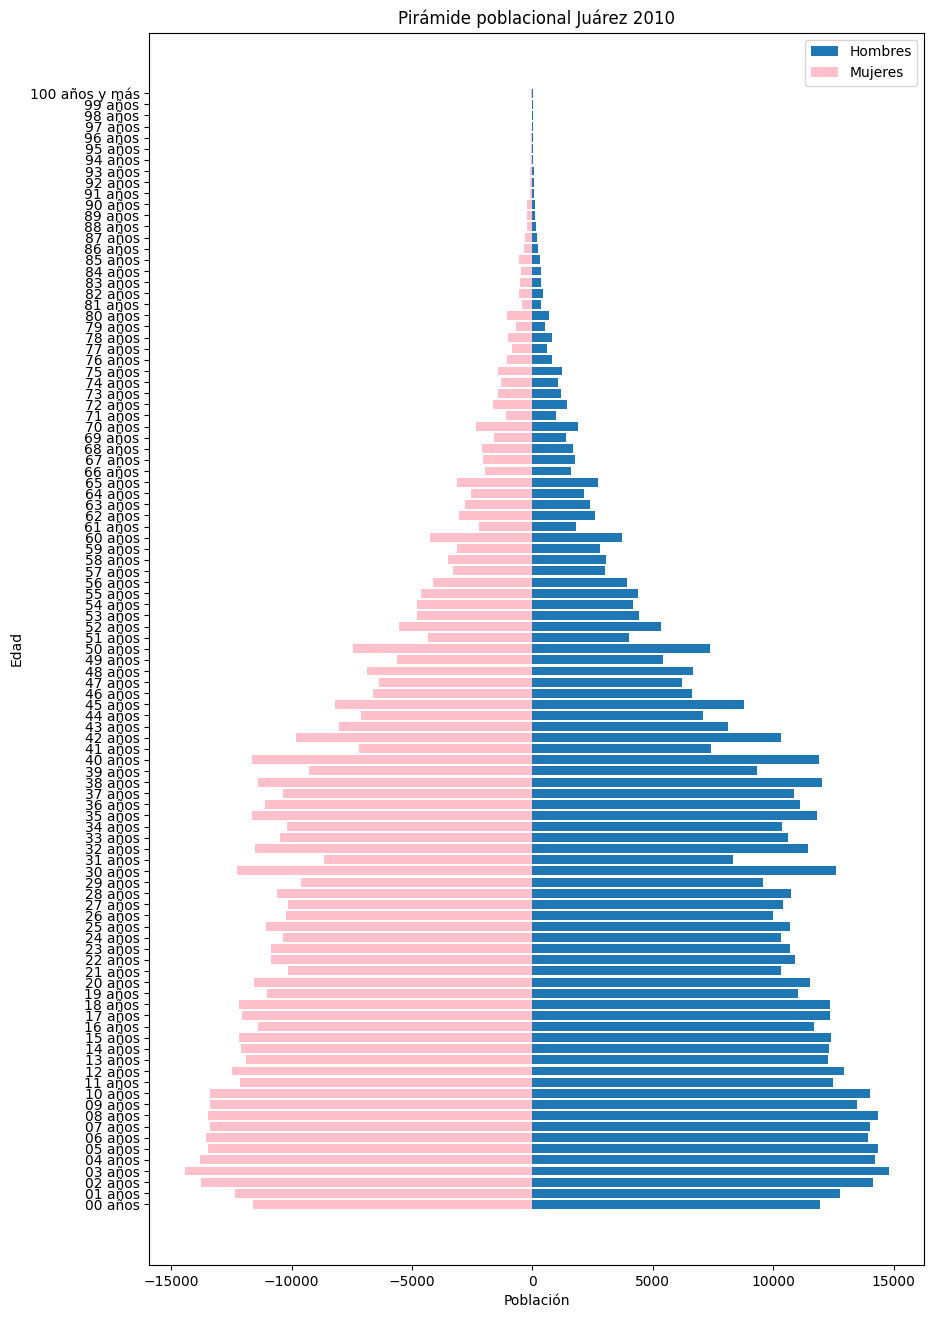

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

chihuahua2010= pd.read_excel('chihuahua_2010.xls', header=4)
chihuahua2020= pd.read_excel('chihuahua.xlsx', sheet_name= '03', header=4)

# Renombramos columnas que no se desplegaron bien
chihuahua2010 = chihuahua2010.rename(columns={
    'Unnamed: 2': 'Edad Desplegada',
    'Unnamed: 4': 'Hombres',
    'Unnamed: 5': 'Mujeres'
})
chihuahua2020 = chihuahua2020.rename(columns={
    'Unnamed: 2': 'Edad Desplegada',
    'Unnamed: 4': 'Hombres',
    'Unnamed: 5': 'Mujeres'
})

# Utilizamos .head() y nos dimos cuenta de que las columnas no tienen nombre
# (unnamed), asi como que hay algunas filas mal escritas
juarez2020 = chihuahua2020[
    (chihuahua2020['Unnamed: 1'] == '037 Juárez') &
    (chihuahua2020['Edad Desplegada'].astype(str).str.contains('años|año', na=False))
].copy()
juarez2010 = chihuahua2010[
    (chihuahua2010['Unnamed: 1'] == '037 Juárez') &
    (chihuahua2010['Edad Desplegada'].astype(str).str.contains('años|año', na=False))
].copy()

# Valores numericos
juarez2010['Hombres'] = pd.to_numeric(juarez2010['Hombres'], errors='coerce')
juarez2010['Mujeres'] = pd.to_numeric(juarez2010['Mujeres'], errors='coerce')
juarez2020['Hombres'] = pd.to_numeric(juarez2020['Hombres'], errors='coerce')
juarez2020['Mujeres'] = pd.to_numeric(juarez2020['Mujeres'], errors='coerce')

# Hacemos drop de NA
juarez2010.dropna(subset=['Hombres', 'Mujeres'], inplace=True)
juarez2020.dropna(subset=['Hombres', 'Mujeres'], inplace=True)


hombres2010 = juarez2010['Hombres']
hombres2010total=  juarez2010['Hombres'].sum()
mujeres2010 = juarez2010['Mujeres']
mujeres2010total=  juarez2010['Mujeres'].sum()

hombres2020 = juarez2020['Hombres']
hombres2020total=  juarez2020['Hombres'].sum()
mujeres2020 = juarez2020['Mujeres']
mujeres2020total=  juarez2020['Hombres'].sum()
edad = juarez2010['Edad Desplegada']
edades_num = juarez2010['Edad Desplegada'].str.extract('(\d+)').astype(int)[0]

modulo_series = edades_num % 10
hombres = juarez2010['Hombres']
mujeres = juarez2010['Mujeres']

plt.figure(figsize=(10,16))
plt.barh(edad, hombres, label='Hombres')
plt.barh(edad, -mujeres, label='Mujeres', color = 'pink')

plt.title("Pirámide poblacional Juárez 2010")
plt.xlabel("Población")
plt.ylabel("Edad")
plt.legend()
plt.show()

INDICE MYERS

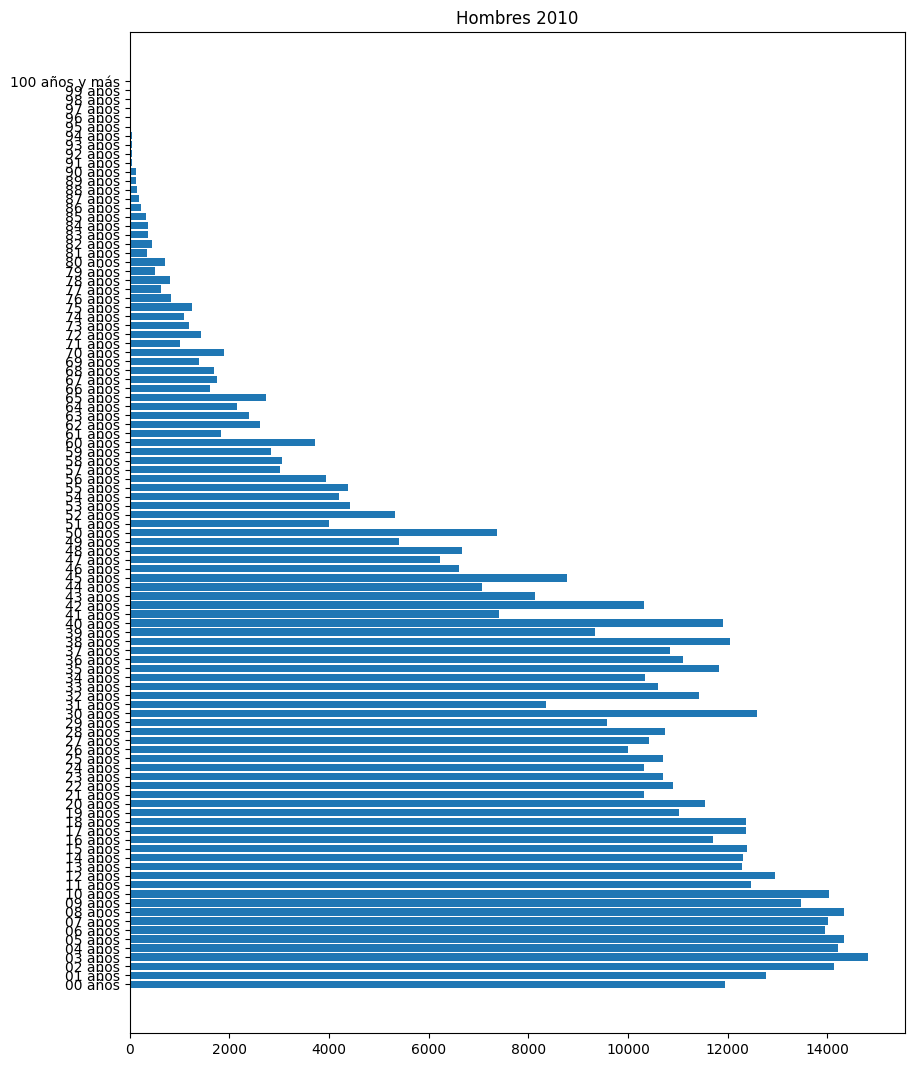

[np.float64(0.01986862672889722), np.float64(-0.007476043186275982), np.float64(0.009988762464418419), np.float64(0.0026535440911267666), np.float64(-0.0018888859034520283), np.float64(0.005468459825415162), np.float64(-0.00515267085084424), np.float64(-0.00602986244687459), np.float64(-0.002249245694253693), np.float64(-0.015182685028157061)]


In [ ]:
plt.figure(figsize=(10,13))
plt.barh(edad, hombres2010)
plt.title('Hombres 2010')
plt.show()
pob_mod2010h = [0]*10

for i in range(len(hombres2010)):
    m = modulo_series.iloc[i]
    pob_mod2010h[m] += hombres2010.iloc[i]

# calcular índices
indices2010h = []

for m in range(10):
    indice2010h = (pob_mod2010h[m] / hombres2010total) - 0.10
    indices2010h.append(indice2010h)

print(indices2010h)




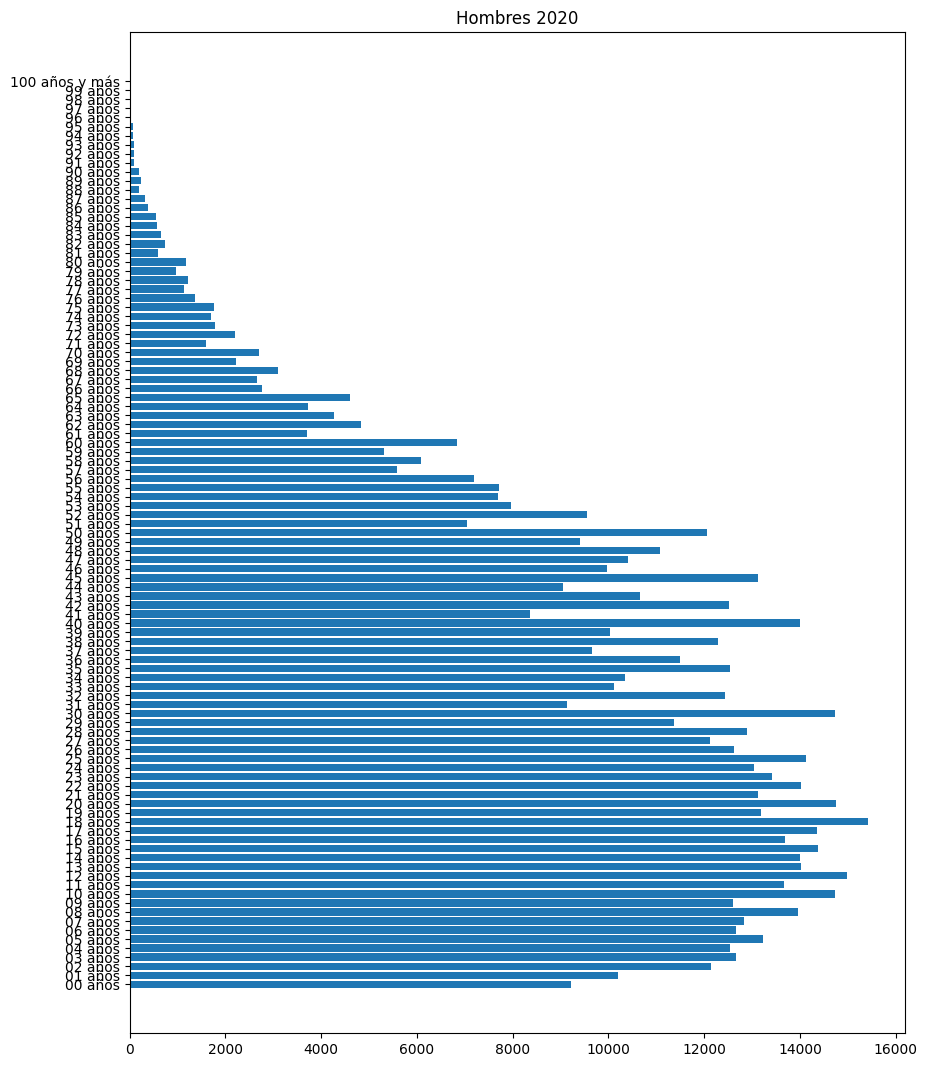

[np.float64(0.019820070487850117), np.float64(-0.01060630150780402), np.float64(0.010640750457111048), np.float64(0.00023054296843945388), np.float64(-0.00364098894983704), np.float64(0.00875135808357845), np.float64(-0.004382966319527254), np.float64(-0.008450592256936174), np.float64(0.001055992792219837), np.float64(-0.013417865755094474)]


In [ ]:
plt.figure(figsize=(10,13))
plt.barh(edad, hombres2020)
plt.title('Hombres 2020')
plt.show()

pob_mod2020h = [0]*10

for i in range(len(hombres2020)):
    m = modulo_series.iloc[i]
    pob_mod2020h[m] += hombres2020.iloc[i]

# calcular índices
indices2020h = []

for m in range(10):
    indice2020h = (pob_mod2020h[m] / hombres2020total) - 0.10
    indices2020h.append(indice2020h)

print(indices2020h)

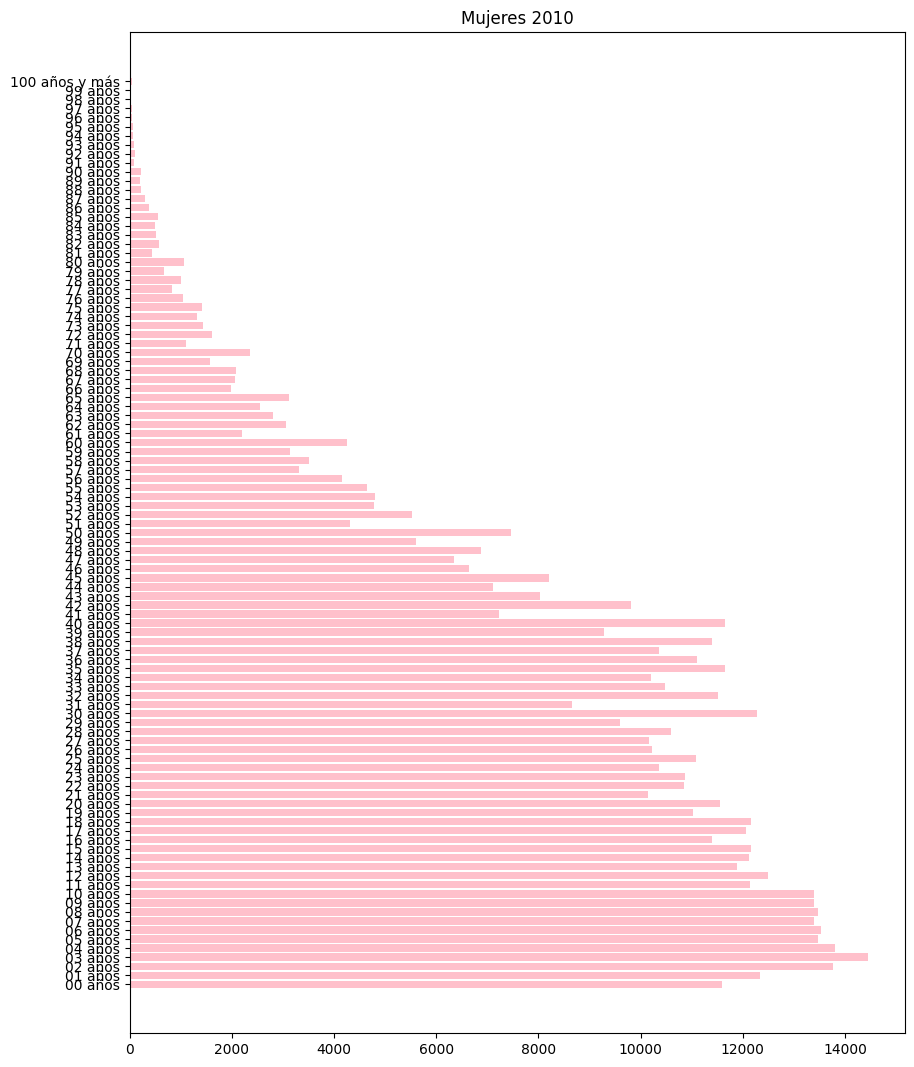

[np.float64(0.019754495470195158), np.float64(-0.007418019135840476), np.float64(0.00938780149367531), np.float64(0.003104956659420871), np.float64(-0.0008620757698458298), np.float64(0.004757755287929516), np.float64(-0.004524437582778068), np.float64(-0.007064411788384947), np.float64(-0.003171573757914728), np.float64(-0.013964490876456861)]


In [ ]:
plt.figure(figsize=(10,13))
plt.barh(edad, mujeres2010, color= 'pink')
plt.title('Mujeres 2010')
plt.show()
# suma de población por módulo
pob_mod2010m = [0]*10

for i in range(len(mujeres2010)):
    m = modulo_series.iloc[i]
    pob_mod2010m[m] += mujeres2010.iloc[i]

# calcular índices
indices2010m = []

for m in range(10):
    indice2010m = (pob_mod2010m[m] / mujeres2010total) - 0.10
    indices2010m.append(indice2010m)

print(indices2010m)

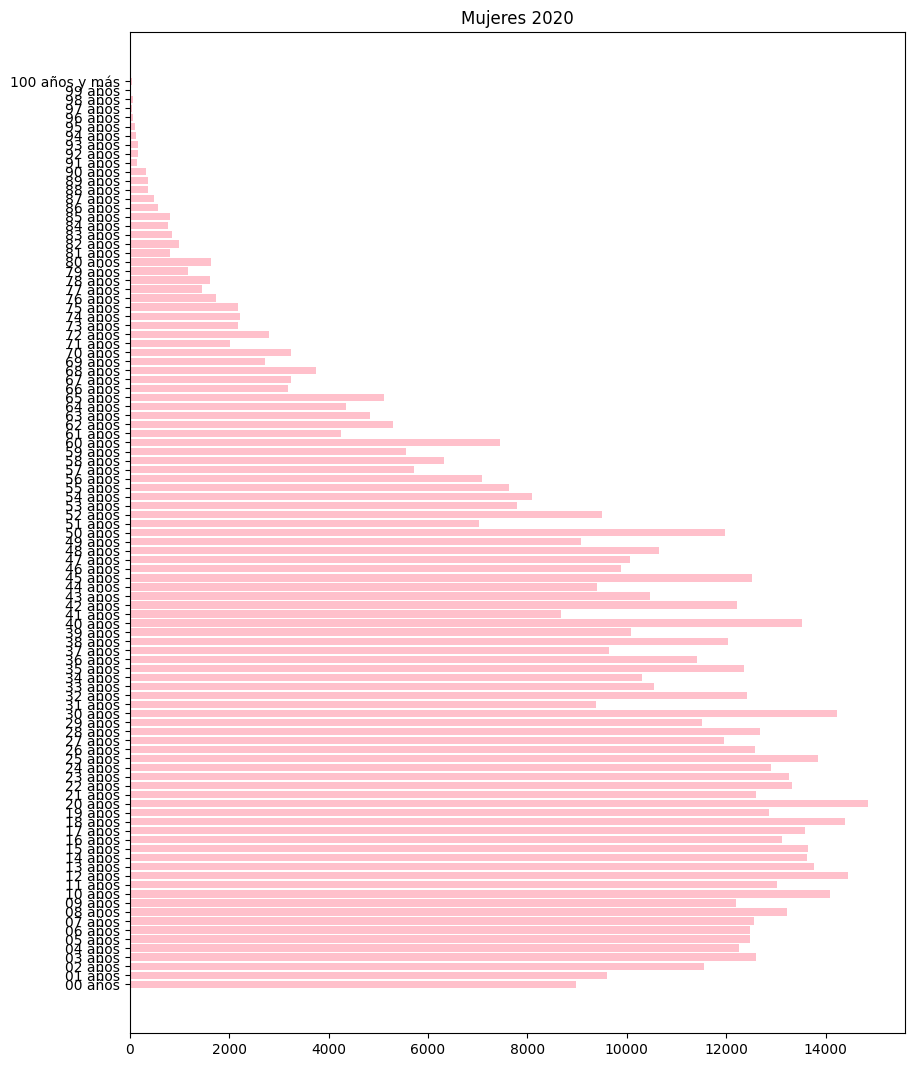

[np.float64(0.01991922807315674), np.float64(-0.010352985534337361), np.float64(0.009816099156700717), np.float64(0.001533126579858518), np.float64(-0.0016942987021263123), np.float64(0.007090511290014229), np.float64(-0.004308367143190953), np.float64(-0.008754540433757466), np.float64(-0.0003295133504683939), np.float64(-0.012919259935849789)]


In [ ]:
plt.figure(figsize=(10,13))
plt.barh(edad, mujeres2020, color = 'pink')
plt.title('Mujeres 2020')
plt.show()
pob_mod2020m = [0]*10
mujeres2020total= mujeres2020.sum()
for i in range(len(mujeres2020)):
    m = modulo_series.iloc[i]
    pob_mod2020m[m] += mujeres2020.iloc[i]

# calcular índices
indices2020m = []

for m in range(10):
    indice2020m = (pob_mod2020m[m] / mujeres2020total) - 0.10
    indices2020m.append(indice2020m)

print(indices2020m)

INDICES WHIPPLE


In [ ]:
# WHIPPLE
suma_h2010 = suma_m2010 = 0
total_h2010 = total_m2010 = 0

suma_h2020 = suma_m2020 = 0
total_h2020 = total_m2020 = 0

for i in range(len(juarez2010)):
    # 2010
    edad_txt_2010 = juarez2010['Edad Desplegada'].iloc[i]
    edad_2010 = int(str(edad_txt_2010).split()[0])

    h2010 = hombres2010.iloc[i]
    m2010 = mujeres2010.iloc[i]

    if 23 <= edad_2010 <= 62:
        total_h2010 += h2010
        total_m2010 += m2010

        if edad_2010 % 10 == 0 or edad_2010 % 10 == 5:
            suma_h2010 += h2010
            suma_m2010 += m2010

    # 2020
    edad_txt_2020 = juarez2020['Edad Desplegada'].iloc[i]
    edad_2020 = int(str(edad_txt_2020).split()[0])

    h2020 = hombres2020.iloc[i]
    m2020 = mujeres2020.iloc[i]

    if 23 <= edad_2020 <= 62:
        total_h2020 += h2020
        total_m2020 += m2020

        if edad_2020 % 10 == 0 or edad_2020 % 10 == 5:
            suma_h2020 += h2020
            suma_m2020 += m2020


# Cálculo
whipple_h2010 = (suma_h2010 / (total_h2010 / 5)) * 100
whipple_m2010 = (suma_m2010 / (total_m2010 / 5)) * 100

whipple_h2020 = (suma_h2020 / (total_h2020 / 5)) * 100
whipple_m2020 = (suma_m2020 / (total_m2020 / 5)) * 100


print("Whipple 2010 Hombres:", whipple_h2010)
print("Whipple 2010 Mujeres:", whipple_m2010)
print("Whipple 2020 Hombres:", whipple_h2020)
print("Whipple 2020 Mujeres:", whipple_m2020)

Whipple 2010 Hombres: 114.89162050084806
Whipple 2010 Mujeres: 113.9770010465708
Whipple 2020 Hombres: 118.18186335280278
Whipple 2020 Mujeres: 116.51647984688918


INDICE INU


In [ ]:
import numpy as np

edades_num = juarez2010['Edad Desplegada'].str.extract(r'(\d+)').astype(int)[0]
# proporciones
ph = hombres2010 / hombres2010total
pm = mujeres2010 / mujeres2010total

# Convertir a arrays
ph = ph.values
pm = pm.values


# agrupamos
def agrupar_5(arr):
    grupos = []
    for i in range(0, len(arr), 5):
        grupos.append(arr[i:i+5].sum())
    return np.array(grupos)

ph_5 = agrupar_5(ph)
pm_5 = agrupar_5(pm)

# indices
IH = []

for i in range(len(ph_5)-2):
    num = ph_5[i] - ph_5[i+2]
    den = ph_5[i] + ph_5[i+2]
    if den != 0:
        IH.append(abs(num / den))
    else:
        IH.append(0)

IH = np.mean(IH) * 100
IM = []

for i in range(len(pm_5)-2):
    num = pm_5[i] - pm_5[i+2]
    den = pm_5[i] + pm_5[i+2]
    if den != 0:
        IM.append(abs(num / den))
    else:
        IM.append(0)

IM = np.mean(IM) * 100
IS = []

for i in range(len(ph_5)-2):
    num = (ph_5[i] - ph_5[i+2]) - (pm_5[i] - pm_5[i+2])
    den = (ph_5[i] + ph_5[i+2]) + (pm_5[i] + pm_5[i+2])
    if den != 0:
        IS.append(abs(num / den))
    else:
        IS.append(0)

IS = np.mean(IS) * 100

INU = IH + IM + 3 * IS

print("IH (Hombres):", IH)
print("IM (Mujeres):", IM)
print("IS (Ambos):", IS)
print("INU:", INU)

IH (Hombres): 32.039076643027194
IM (Mujeres): 29.590926121276002
IS (Ambos): 3.6913252902729163
INU: 72.70397863512196


Proporcionales no especificados 2010

In [ ]:


# población no especificada (ajusta esto si ya lo tienes calculado)
total_2010 = hombres2010total+ mujeres2010total
no_esp_2010 = 32990+32969
# listas para población corregida
hombres2010_corr = []
mujeres2010_corr = []

for i in range(len(juarez2010)):
    h = hombres2010.iloc[i]
    m = mujeres2010.iloc[i]

    # proporción dentro del total (sexo + edad)
    prop_h = h / total_2010
    prop_m = m / total_2010

    # parte que le toca del no especificado
    add_h = prop_h * no_esp_2010
    add_m = prop_m * no_esp_2010

    # población corregida
    hombres2010_corr.append(h + add_h)
    mujeres2010_corr.append(m + add_m)

print("Primeros valores corregidos hombres:", hombres2010_corr[:5])
print("Primeros valores corregidos mujeres:", mujeres2010_corr[:5])
#Entonces ya podemos asignar
juarez2010['Poblacion Hombres Corregida']= [round(h) for h in hombres2010_corr]
juarez2010['Poblacion Mujeres Corregida']= [round(m) for m in mujeres2010_corr]
print(juarez2010.head())

Primeros valores corregidos hombres: [np.float64(12572.514200282427), np.float64(13442.595308536282), np.float64(14873.442112919887), np.float64(15582.552955680587), np.float64(14949.192826093138)]
Primeros valores corregidos mujeres: [np.float64(12196.916914131729), np.float64(12977.57009711161), np.float64(14482.06342819143), np.float64(15199.591016860268), np.float64(14519.938784778056)]
        Unnamed: 0  Unnamed: 1 Edad Desplegada Unnamed: 3  Hombres  Mujeres  \
3601  08 Chihuahua  037 Juárez         00 años      23543    11950    11593   
3602  08 Chihuahua  037 Juárez         01 años      25112    12777    12335   
3603  08 Chihuahua  037 Juárez         02 años      27902    14137    13765   
3604  08 Chihuahua  037 Juárez         03 años      29258    14811    14447   
3605  08 Chihuahua  037 Juárez         04 años      28010    14209    13801   

      Poblacion Hombres Corregida  Poblacion Mujeres Corregida  
3601                        12573                        12197  
3

Proporcionales no especificados 2020

In [ ]:


total_2020 = hombres2020total+ mujeres2020total
no_esp_2020 = 2237 + 2241  # población no especificada 2020

hombres2020_corr = []
mujeres2020_corr = []

for i in range(len(juarez2020)):
    h1 = hombres2020.iloc[i]
    m1 = mujeres2020.iloc[i]

    # proporción dentro del total especificado
    prop_h1 = h1 / total_2020
    prop_m1 = m1 / total_2020

    # parte que le toca del no especificado
    add_h1 = prop_h1 * no_esp_2020
    add_m1 = prop_m1 * no_esp_2020

    # población corregida
    hombres2020_corr.append(h1 + add_h1)
    mujeres2020_corr.append(m1 + add_m1)

#Entonces ya podemos asignar
juarez2020['Poblacion Hombres Corregida']= [round(h) for h in hombres2020_corr]
juarez2020['Poblacion Mujeres Corregida']= [round(m) for m in mujeres2020_corr]
print(juarez2020.head())

        Unnamed: 0  Unnamed: 1 Edad Desplegada Unnamed: 3  Hombres  Mujeres  \
3614  08 Chihuahua  037 Juárez         00 años      18183     9216     8967   
3615  08 Chihuahua  037 Juárez         01 años      19793    10191     9602   
3616  08 Chihuahua  037 Juárez         02 años      23685    12136    11549   
3617  08 Chihuahua  037 Juárez         03 años      25277    12671    12606   
3618  08 Chihuahua  037 Juárez         04 años      24796    12534    12262   

      Unnamed: 6  Poblacion Hombres Corregida  Poblacion Mujeres Corregida  
3614  102.776848                         9243                         8994  
3615  106.134139                        10221                         9631  
3616  105.082691                        12172                        11583  
3617  100.515627                        12709                        12643  
3618  102.218235                        12571                        12298  


Spline


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17318/3717958053.py:7: SyntaxWarning: invalid escape sequence '\d'
  juarez2010['Edad'] = juarez2010['Edad Desplegada'].str.extract('(\d+)').astype(int)


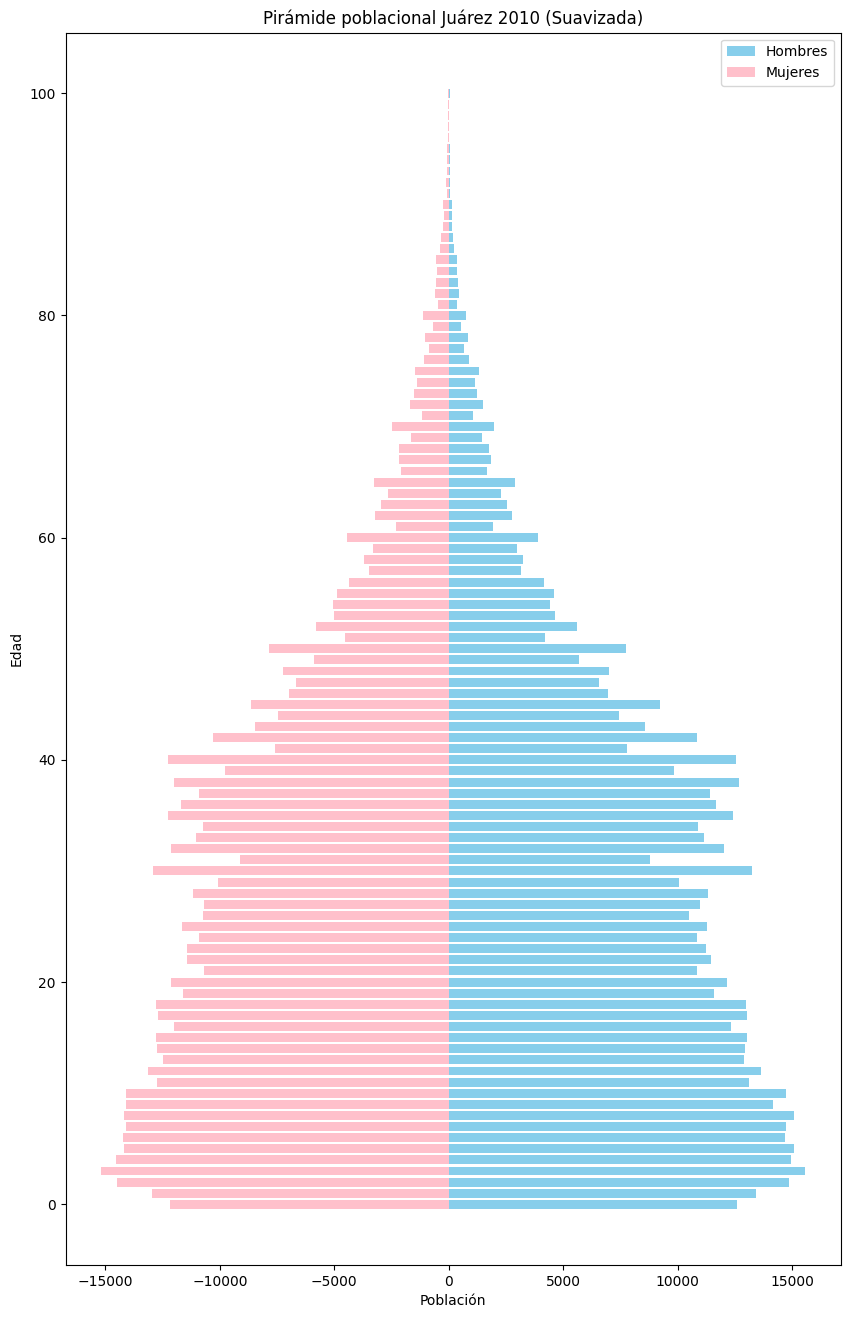

In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt

# Tomamos edades y población corregida
# Extraemos la edad numérica
juarez2010['Edad'] = juarez2010['Edad Desplegada'].str.extract('(\d+)').astype(int)

x_edad = juarez2010['Edad']  # edades originales
y_h = juarez2010['Poblacion Hombres Corregida']
y_m = juarez2010['Poblacion Mujeres Corregida']


x_nuevo = np.arange(0, 101)

# Aplicar splines
spline_h = UnivariateSpline(x_edad, y_h, s=0)
spline_m = UnivariateSpline(x_edad, y_m, s=0)

# Población suavizada
h_suav = spline_h(x_nuevo)
m_suav = spline_m(x_nuevo)

# Factor de cuadratura
factor_h = sum(y_h) / sum(h_suav)
factor_m = sum(y_m) / sum(m_suav)

h_final = h_suav * factor_h
m_final = m_suav * factor_m

# Redondear a enteros
h_final = [round(x) for x in h_final]
m_final = [round(x) for x in m_final]

spline2010 = pd.DataFrame({
    'Edad': x_nuevo,
    'Hombres Suavizados': h_final,
    'Mujeres Suavizadas': m_final
})

# Grafica suavizada
plt.figure(figsize=(10,16))
plt.barh(x_nuevo, h_final, label='Hombres', color='skyblue')
plt.barh(x_nuevo, -np.array(m_final), label='Mujeres', color='pink')
plt.xlabel("Población")
plt.ylabel("Edad")
plt.title("Pirámide poblacional Juárez 2010 (Suavizada)")
plt.legend()
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17318/2802680465.py:7: SyntaxWarning: invalid escape sequence '\d'
  juarez2020['Edad'] = juarez2020['Edad Desplegada'].str.extract('(\d+)').astype(int)


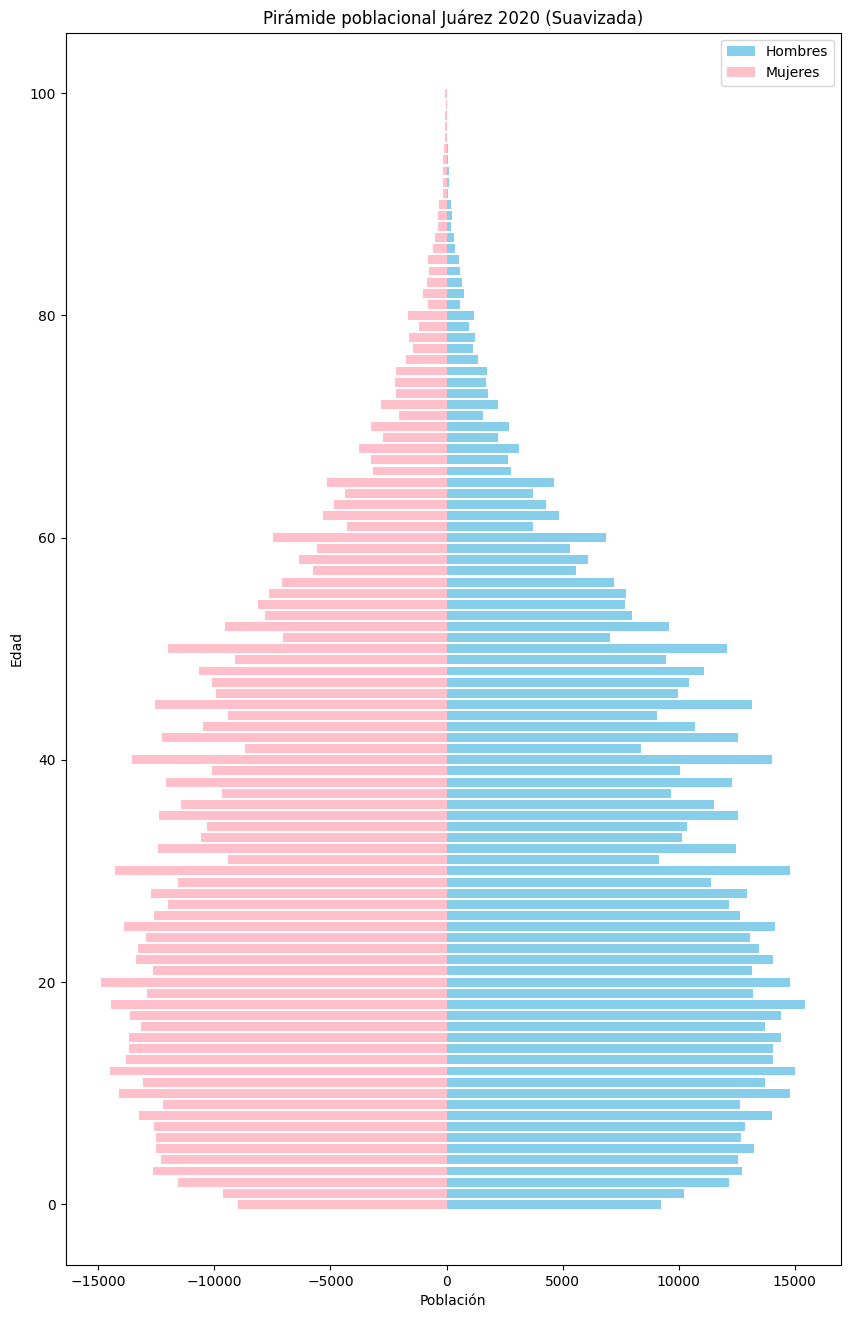

In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt


# Extraemos la edad numérica
juarez2020['Edad'] = juarez2020['Edad Desplegada'].str.extract('(\d+)').astype(int)

x_edad1 = juarez2020['Edad']  # edades originales
y_h1 = juarez2020['Poblacion Hombres Corregida']
y_m1 = juarez2020['Poblacion Mujeres Corregida']

# Rango de edades 0 a 100
x_nuevo1 = np.arange(0, 101)

# Aplicar splines
spline_h1 = UnivariateSpline(x_edad1, y_h1, s=0)
spline_m1 = UnivariateSpline(x_edad1, y_m1, s=0)

# Población suavizada
h_suav1 = spline_h1(x_nuevo1)
m_suav1 = spline_m1(x_nuevo1)

# Factor de cuadratura Para que el total no cambie
factor_h1 = sum(y_h1) / sum(h_suav1)
factor_m1= sum(y_m1) / sum(m_suav1)

h_final1 = h_suav1 * factor_h1
m_final1 = m_suav1 * factor_m1

# Redondear a enteros
h_final1 = [round(x) for x in h_final1]
m_final1 = [round(x) for x in m_final1]

# Guardar en DataFrame
spline2020 = pd.DataFrame({
    'Edad': x_nuevo1,
    'Hombres Suavizados': h_final1,
    'Mujeres Suavizadas': m_final1
})

# Graficar la pirámide
plt.figure(figsize=(10,16))
plt.barh(x_nuevo1, h_final1, label='Hombres', color='skyblue')
plt.barh(x_nuevo1, -np.array(m_final1), label='Mujeres', color='pink')
plt.xlabel("Población")
plt.ylabel("Edad")
plt.title("Pirámide poblacional Juárez 2020 (Suavizada)")
plt.legend()
plt.show()

Grupos Quinquenales y Dependencia 2010

In [ ]:
años = list(range(0, 105, 5))
labels = [f'{b}-{b+4}' for b in años[:-1]]

# Crear columna de quinquenios
spline2010['Quinquenales'] = pd.cut(spline2010['Edad'], bins=años, labels=labels)

# Agrupar por quinquenios
spline2010_suma = spline2010.groupby('Quinquenales')[['Hombres Suavizados','Mujeres Suavizadas']].sum()

# Calcular índice de masculinidad por quinquenio
spline2010_suma['Indice Masculinidad'] = (spline2010_suma['Hombres Suavizados'] / spline2010_suma['Mujeres Suavizadas']) * 100

print(spline2010_suma)

#DEPENDENCIA
# Hombres

h_dep1 = spline2010.loc[(spline2010['Edad'] <= 14) | (spline2010['Edad'] >= 65), 'Hombres Suavizados'].sum()
h_prod1 = spline2010.loc[(spline2010['Edad'] >= 15) & (spline2010['Edad'] <= 64), 'Hombres Suavizados'].sum()
razon_dep_h1 = (h_dep1 / h_prod1) * 100

# Mujeres
m_dep1 = spline2010.loc[(spline2010['Edad'] <= 14) | (spline2010['Edad'] >= 65), 'Mujeres Suavizadas'].sum()
m_prod1 = spline2010.loc[(spline2010['Edad'] >= 15) & (spline2010['Edad'] <= 64), 'Mujeres Suavizadas'].sum()
razon_dep_m1 = (m_dep1 / m_prod1) * 100

print(f"Razón de dependencia Hombres 2010: {razon_dep_h1:.2f}%")
print(f"Razón de dependencia Mujeres 2010: {razon_dep_m1:.2f}%")

              Hombres Suavizados  Mujeres Suavizadas  Indice Masculinidad
Quinquenales                                                             
0-4                        73929               71358           103.602960
5-9                        73413               70696           103.843216
10-14                      65637               63958           102.625160
15-19                      62089               61232           101.399595
20-24                      55705               56078            99.334855
25-29                      56104               55605           100.897401
30-34                      55280               55256           100.043434
35-39                      58122               56592           102.703562
40-44                      43889               42487           103.299833
45-49                      33945               34647            97.973851
50-54                      23472               25322            92.694100
55-59                      17418      

/tmp/ipykernel_17318/2377789947.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spline2010_suma = spline2010.groupby('Quinquenales')[['Hombres Suavizados','Mujeres Suavizadas']].sum()


Grupos Quinquenales y Dependencia 2020


In [ ]:

# Crear columna de quinquenios
spline2020['Quinquenales'] = pd.cut(spline2020['Edad'], bins=años, labels=labels)

# Agrupar por quinquenios
spline2020_suma = spline2020.groupby('Quinquenales')[['Hombres Suavizados','Mujeres Suavizadas']].sum()

# índice de masculinidad
spline2020_suma['Indice Masculinidad'] = (spline2020_suma['Hombres Suavizados'] / spline2020_suma['Mujeres Suavizadas']) * 100

print(spline2020_suma)

#DEPENDENCIA
# Hombres

h_dep = spline2020.loc[(spline2020['Edad'] <= 14) | (spline2020['Edad'] >= 65), 'Hombres Suavizados'].sum()
h_prod = spline2020.loc[(spline2020['Edad'] >= 15) & (spline2020['Edad'] <= 64), 'Hombres Suavizados'].sum()
razon_dep_h = (h_dep / h_prod) * 100

# Mujeres
m_dep = spline2020.loc[(spline2020['Edad'] <= 14) | (spline2020['Edad'] >= 65), 'Mujeres Suavizadas'].sum()
m_prod = spline2020.loc[(spline2020['Edad'] >= 15) & (spline2020['Edad'] <= 64), 'Mujeres Suavizadas'].sum()
razon_dep_m = (m_dep / m_prod) * 100

print(f"Razón de dependencia Hombres 2020: {razon_dep_h:.2f}%")
print(f"Razón de dependencia Mujeres 2020: {razon_dep_m:.2f}%")

              Hombres Suavizados  Mujeres Suavizadas  Indice Masculinidad
Quinquenales                                                             
0-4                        60941               58673           103.865492
5-9                        66979               64728           103.477629
10-14                      71276               68709           103.736046
15-19                      71608               68993           103.790240
20-24                      67937               66136           102.723176
25-29                      63948               63150           101.263658
30-34                      54726               55171            99.193417
35-39                      57645               56861           101.378801
40-44                      53868               53417           100.844301
45-49                      53076               51790           102.483105
50-54                      40061               40132            99.823084
55-59                      31104      

/tmp/ipykernel_17318/1874674688.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spline2020_suma = spline2020.groupby('Quinquenales')[['Hombres Suavizados','Mujeres Suavizadas']].sum()


PIRAMIDE POBLACIONAL 2010

/tmp/ipykernel_17318/1204391182.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spline2010_suma = spline2010.groupby('Quinquenales')[['Hombres Suavizados','Mujeres Suavizadas']].sum()


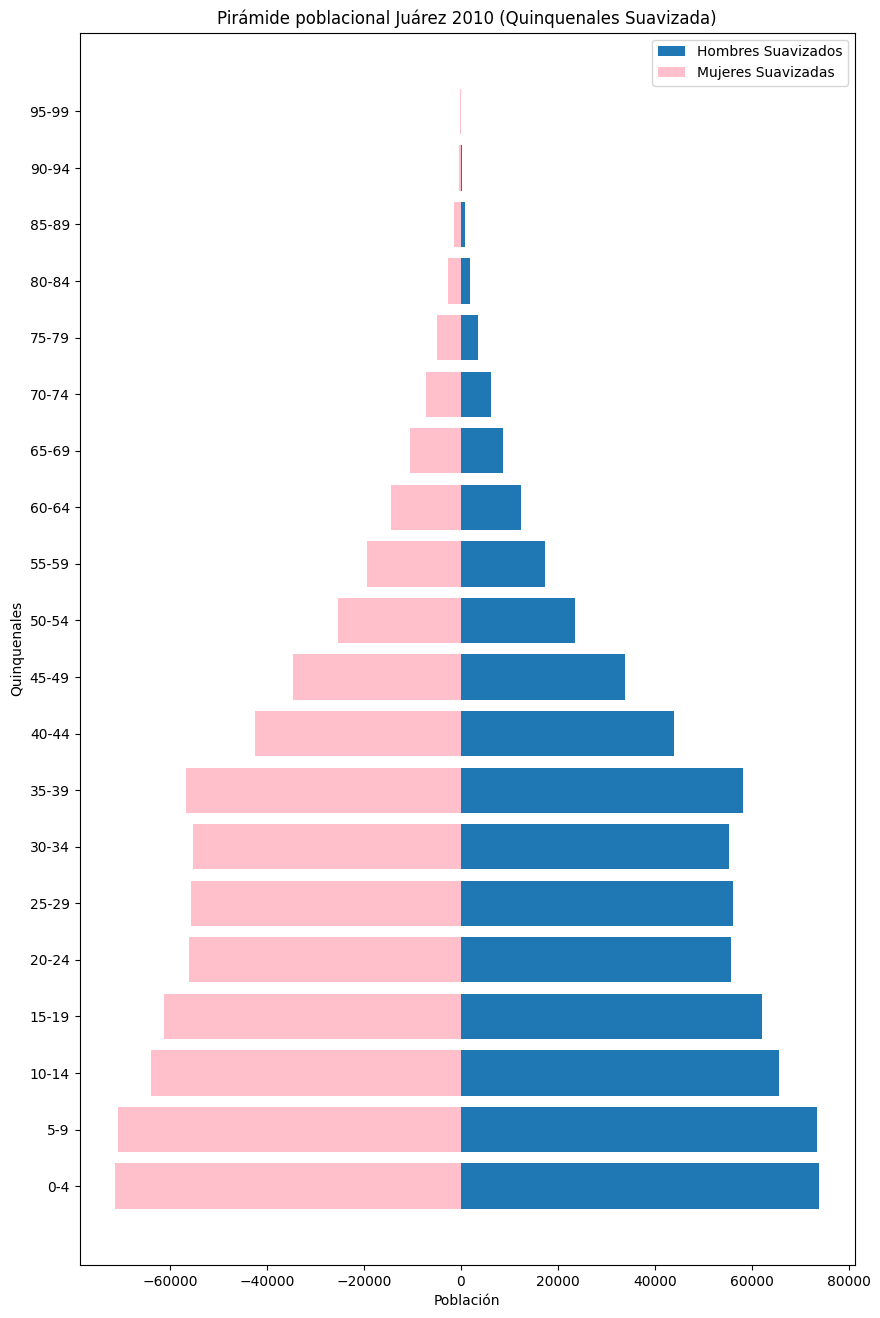

In [ ]:
años = list(range(0, 105, 5))
labels = [f'{b}-{b+4}' for b in años[:-1]]

# Crear columna de quinquenios
spline2010['Quinquenales'] = pd.cut(spline2010['Edad'], bins=años, labels=labels)

# Agrupar por quinquenios y sumar población suavizada
spline2010_suma = spline2010.groupby('Quinquenales')[['Hombres Suavizados','Mujeres Suavizadas']].sum()

# Calcular índice de masculinidad por quinquenio
spline2010_suma['Indice Masculinidad'] = (spline2010_suma['Hombres Suavizados'] / spline2010_suma['Mujeres Suavizadas']) * 100

plt.figure(figsize=(10,16))

plt.barh(spline2010_suma.index, spline2010_suma['Hombres Suavizados'], label='Hombres Suavizados')
plt.barh(spline2010_suma.index, -spline2010_suma['Mujeres Suavizadas'], label='Mujeres Suavizadas', color='pink')

plt.xlabel("Población")
plt.ylabel("Quinquenales")
plt.title("Pirámide poblacional Juárez 2010 (Quinquenales Suavizada)")
plt.legend()
plt.show()

PIRAMIDE POBLACIONAL QUINQUENAL 2020

/tmp/ipykernel_17318/2711065523.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spline2020_suma = spline2020.groupby('Quinquenales')[['Hombres Suavizados','Mujeres Suavizadas']].sum()


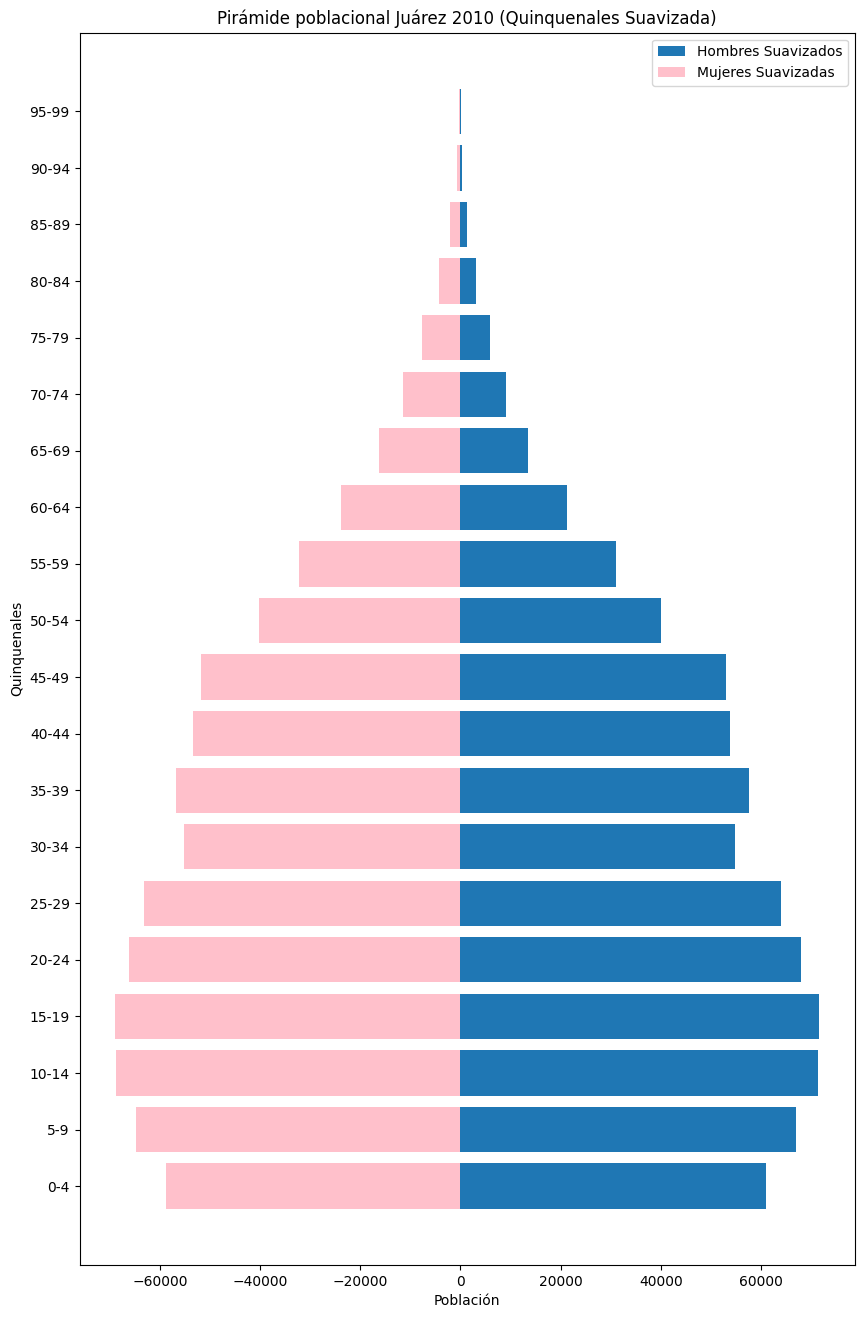

In [ ]:
# Agrupar por quinquenios
spline2020_suma = spline2020.groupby('Quinquenales')[['Hombres Suavizados','Mujeres Suavizadas']].sum()

# Calcular índice de masculinidad por quinquenio
spline2020_suma['Indice Masculinidad'] = (spline2020_suma['Hombres Suavizados'] / spline2010_suma['Mujeres Suavizadas']) * 100

plt.figure(figsize=(10,16))

plt.barh(spline2020_suma.index, spline2020_suma['Hombres Suavizados'], label='Hombres Suavizados')
plt.barh(spline2020_suma.index, -spline2020_suma['Mujeres Suavizadas'], label='Mujeres Suavizadas', color='pink')

plt.xlabel("Población")
plt.ylabel("Quinquenales")
plt.title("Pirámide poblacional Juárez 2010 (Quinquenales Suavizada)")
plt.legend()
plt.show()